In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *
from sklearn import tree

In [3]:
df = pd.read_csv("/Users/anuragpanchal/Documents/MachineLearning/DecisionTree-Heart/heart.csv")

In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [5]:
df.shape

(303, 14)

In [6]:
cols = df.columns
cols

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [10]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(1)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df['target'].value_counts(normalize=True)

target
1    0.543046
0    0.456954
Name: proportion, dtype: float64

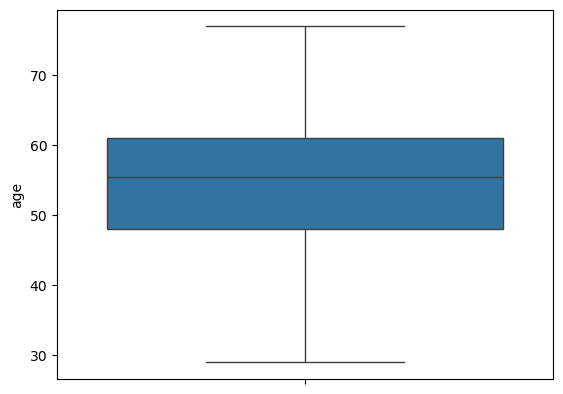

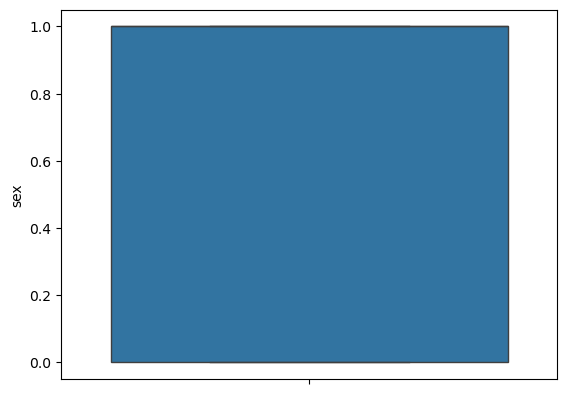

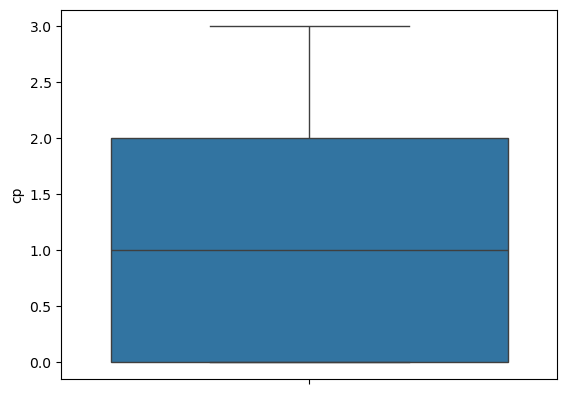

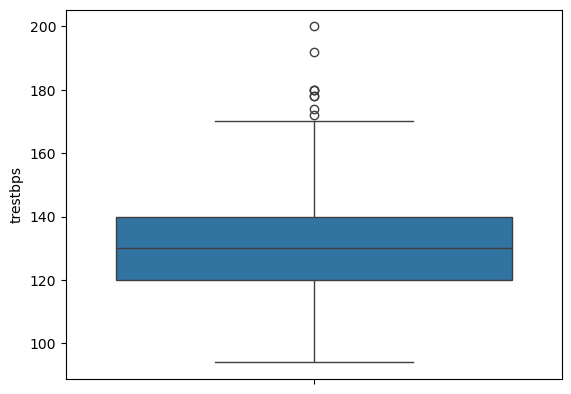

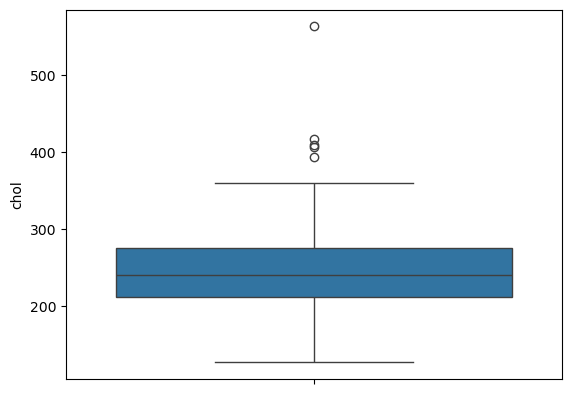

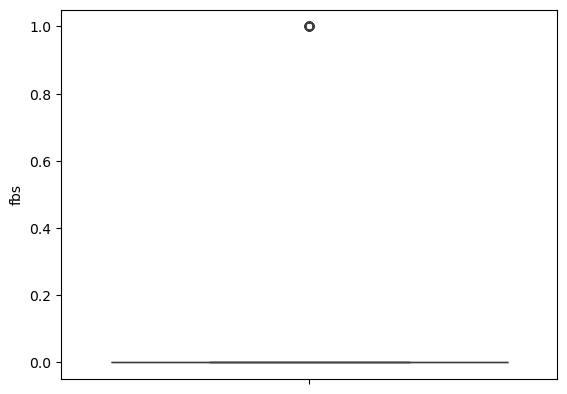

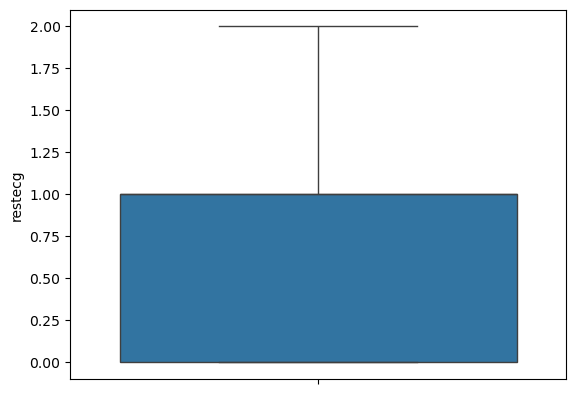

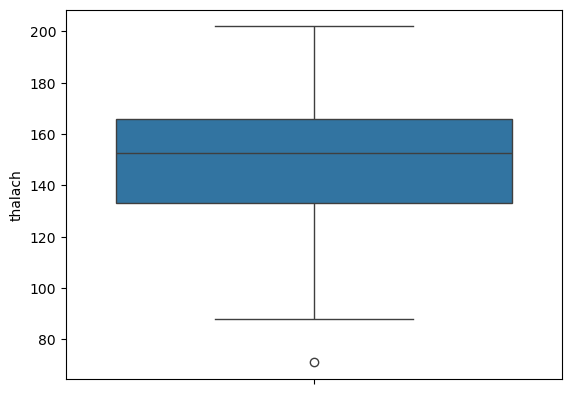

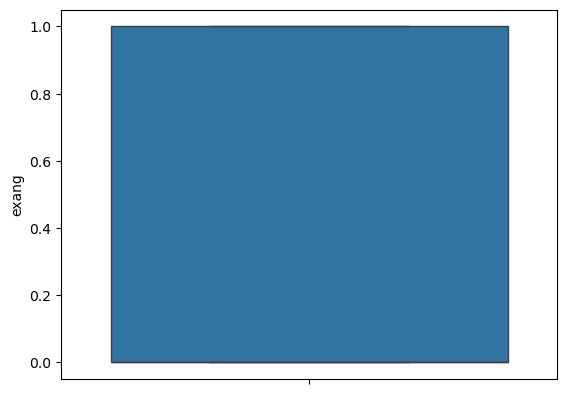

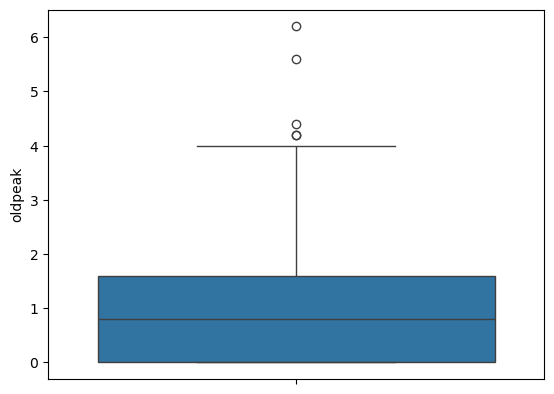

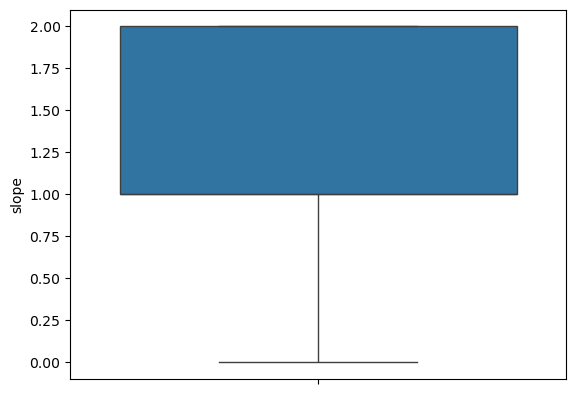

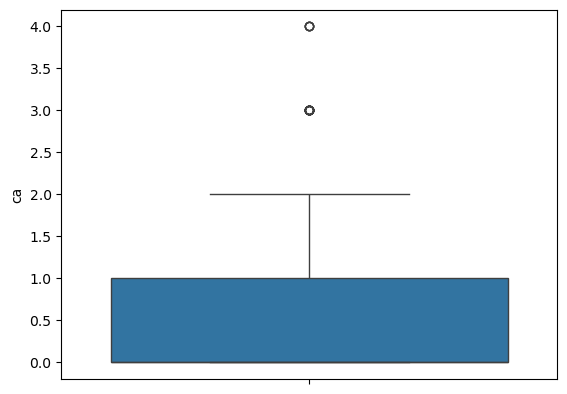

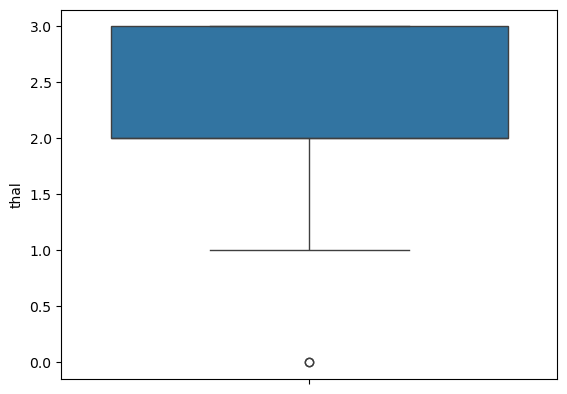

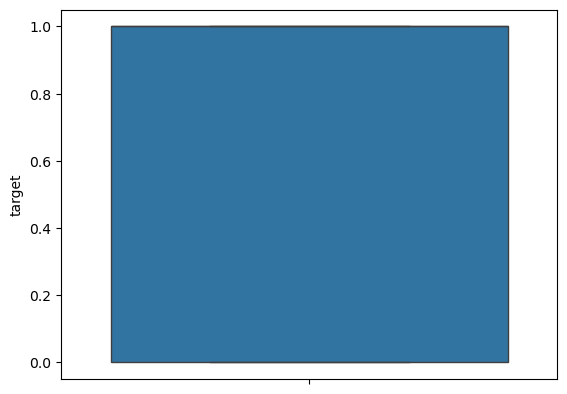

In [14]:
for i in cols:
    if df[i].dtypes!="object":
        sns.boxplot(df[i])
        plt.show()

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5]),
 [Text(0.5, 0, 'age'),
  Text(1.5, 0, 'sex'),
  Text(2.5, 0, 'cp'),
  Text(3.5, 0, 'trestbps'),
  Text(4.5, 0, 'chol'),
  Text(5.5, 0, 'fbs'),
  Text(6.5, 0, 'restecg'),
  Text(7.5, 0, 'thalach'),
  Text(8.5, 0, 'exang'),
  Text(9.5, 0, 'oldpeak'),
  Text(10.5, 0, 'slope'),
  Text(11.5, 0, 'ca'),
  Text(12.5, 0, 'thal'),
  Text(13.5, 0, 'target')])

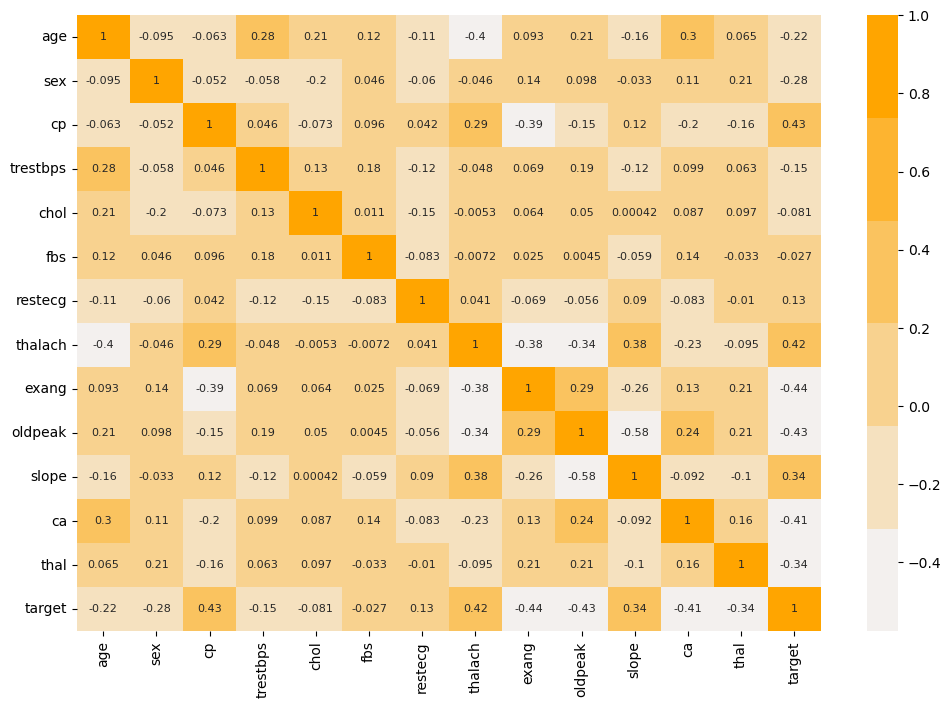

In [15]:
plt.figure(figsize=(12,8))
palette = sns.light_palette("orange")
sns.heatmap(df.corr(),annot=True,cmap=palette,annot_kws={'size':8})
plt.xticks(rotation=90)

In [16]:
x= df.drop(columns = "target")
y = df['target']

In [17]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.20,random_state=38)

In [18]:
x_train.shape,x_test.shape ,y_train.shape,y_test.shape

((241, 13), (61, 13), (241,), (61,))

In [19]:
model = DecisionTreeClassifier()

In [20]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [21]:
y_pred = model.predict(x_test)

In [22]:
data  = pd.DataFrame()

In [23]:
data['y_test'] = y_test
data['y_pred']= y_pred

In [24]:
data

,y_test,y_pred
167,0,0
91,1,0
134,1,1
80,1,1
103,1,1
...,...,...
73,1,1
118,1,1
8,1,1
58,1,1


In [25]:
accuracy_score(y_test,y_pred)

0.8360655737704918

In [26]:
cm = confusion_matrix(y_test,y_pred)

In [27]:
cm

array([[23,  5],
       [ 5, 28]])

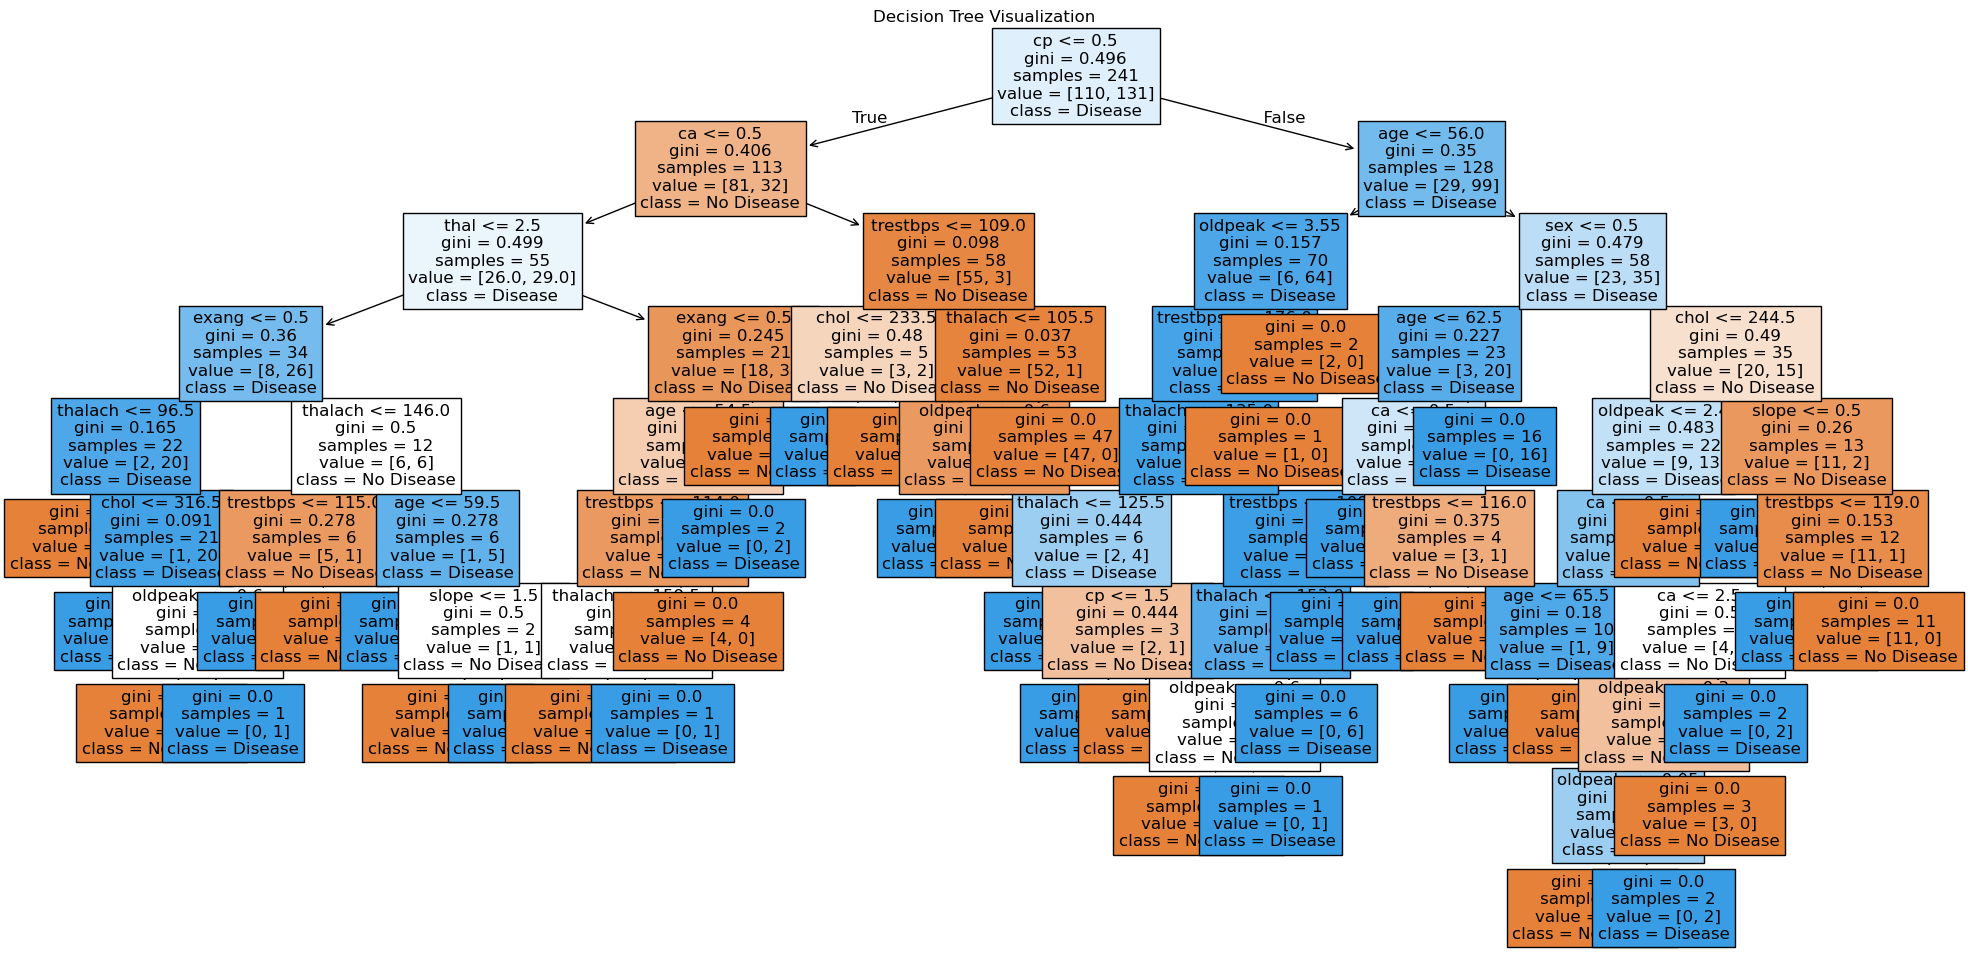

In [28]:
plt.figure(figsize=(24,12))
tree.plot_tree(model,feature_names = x.columns,class_names=['No Disease','Disease'],filled=True,fontsize=12)
plt.title("Decision Tree Visualization")
plt.show()

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
model2 = LogisticRegression()

In [31]:
model2.fit(x_train,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [32]:
y_pred2 = model2.predict(x_test)

In [33]:
accuracy_score(y_test,y_pred2)

0.8688524590163934

In [34]:
depths = [1,2,3,4,5,6,7,8,9,11,12]
for i in depths:
    model = DecisionTreeClassifier(max_depth=i,random_state=60)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    acc= accuracy_score(y_test,y_pred)
    print(f"When depth: {i} and {acc}")

When depth: 1 and 0.8032786885245902
When depth: 2 and 0.8032786885245902
When depth: 3 and 0.819672131147541
When depth: 4 and 0.8032786885245902
When depth: 5 and 0.8360655737704918
When depth: 6 and 0.8360655737704918
When depth: 7 and 0.8032786885245902
When depth: 8 and 0.8360655737704918
When depth: 9 and 0.819672131147541
When depth: 11 and 0.819672131147541
When depth: 12 and 0.819672131147541


In [35]:
model.get_depth()

9

In [36]:
new_model = DecisionTreeClassifier()

In [40]:
from sklearn.model_selection import GridSearchCV

param = {
    'criterion':['gini','Entropy'],
    'max_depth':[1,5,50,100],
    'random_state':[0,1,2,3,4,5,22],
    'min_samples_split':[2,4,6,8,9,3,5,22],
    'min_samples_leaf':[1,4,3,6,5],
    'max_features':[1,2,3,4,5,6]
}

In [41]:
gv = GridSearchCV(estimator=new_model,param_grid=param,cv=3)

In [42]:
gv.fit(x_train,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20160 fits failed out of a total of 40320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20160 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 436, in _validat

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'Entropy'],
                         'max_depth': [1, 5, 50, 100],
                         'max_features': [1, 2, 3, 4, 5, 6],
                         'min_samples_leaf': [1, 4, 3, 6, 5],
                         'min_samples_split': [2, 4, 6, 8, 9, 3, 5, 22],
                         'random_state': [0, 1, 2, 3, 4, 5, 22]})

In [43]:
gv.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 4,
 'min_samples_leaf': 5,
 'min_samples_split': 22,
 'random_state': 5}

In [44]:
dt_model =gv.best_estimator_

In [46]:
y_pred_gv = dt_model.predict(x_test)

In [47]:
accuracy_score(y_test,y_pred_gv)

0.8360655737704918

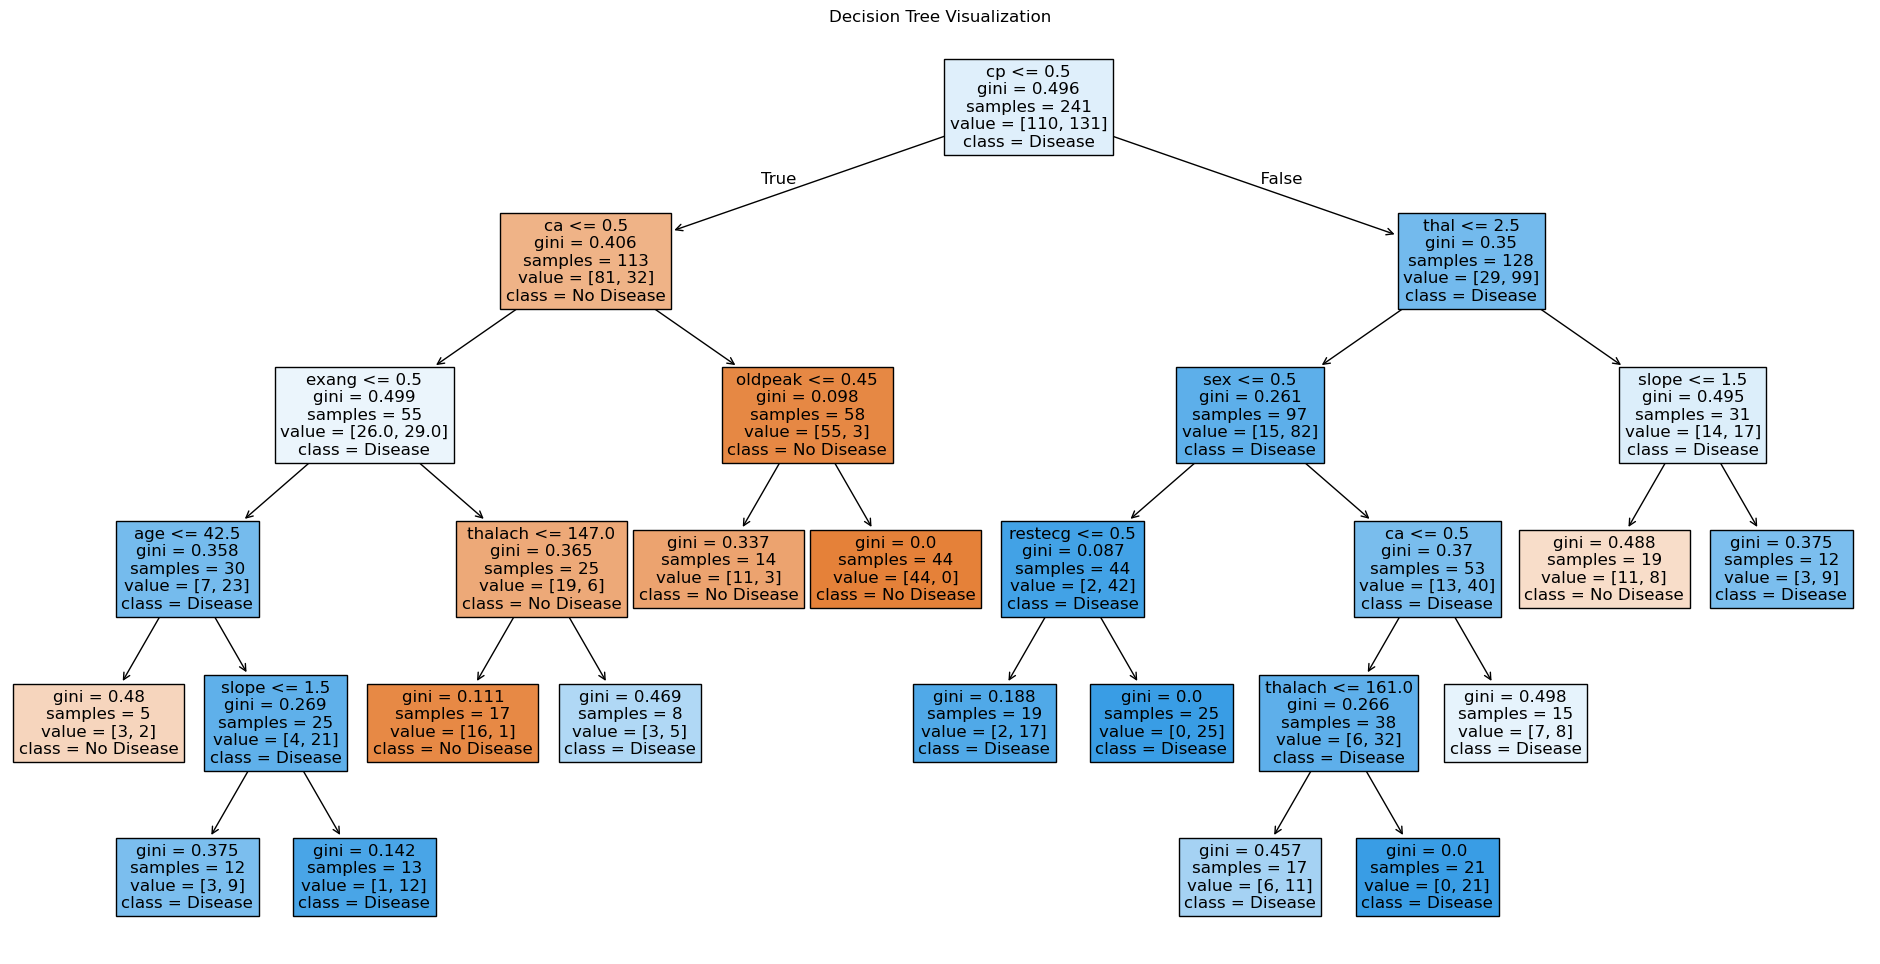

In [48]:
plt.figure(figsize=(24,12))
tree.plot_tree(dt_model,feature_names = x.columns,class_names=['No Disease','Disease'],filled=True,fontsize=12)
plt.title("Decision Tree Visualization")
plt.show()

In [49]:
from sklearn.model_selection import RandomizedSearchCV

In [50]:
new_model1 = DecisionTreeClassifier()

In [51]:
rv = RandomizedSearchCV(estimator=new_model1,param_distributions=param,random_state=42,cv =3,n_jobs=-1)

In [52]:
rv.fit(x_train,y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 436, in _validate_params
 

RandomizedSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'Entropy'],
                                        'max_depth': [1, 5, 50, 100],
                                        'max_features': [1, 2, 3, 4, 5, 6],
                                        'min_samples_leaf': [1, 4, 3, 6, 5],
                                        'min_samples_split': [2, 4, 6, 8, 9, 3,
                                                              5, 22],
                                        'random_state': [0, 1, 2, 3, 4, 5, 22]},
                   random_state=42)

In [55]:
rv.best_params_



{'random_state': 0,
 'min_samples_split': 22,
 'min_samples_leaf': 4,
 'max_features': 5,
 'max_depth': 100,
 'criterion': 'gini'}

Exception ignored in: <function ResourceTracker.__del__ at 0x1025d1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1069d5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1030a5bc0>
Traceback (most recent call last

In [53]:
dt_model1 = rv.best_estimator_

In [54]:
y_pred3 = dt_model1.predict(x_test)
accuracy_score(y_test,y_pred3)

0.8360655737704918